In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [46]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [47]:
from data_science.plots import plot_confusion_matrix
from data_science.styles import apply_luna_style

In [48]:
apply_luna_style()

## Data

In [49]:
data = pd.read_csv(
    "./../data/wheat-seeds.csv",
    names=[
        "area",
        "perimeter",
        "compactness",
        "length of kernel",
        "width of kernel",
        "asymmetry coefficient",
        "length of groove",
        "type",
    ],
    header=None,
)

In [50]:
label_map = {1: "Kama", 2: "Rosa", 3: "Canadian"}
data["type"] = data["type"].map(label_map)

## Basic Statistics


In [51]:
data.head()

,area,perimeter,compactness,length of kernel,width of kernel,asymmetry coefficient,length of groove,type
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Kama


In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area                   210 non-null    float64
 1   perimeter              210 non-null    float64
 2   compactness            210 non-null    float64
 3   length of kernel       210 non-null    float64
 4   width of kernel        210 non-null    float64
 5   asymmetry coefficient  210 non-null    float64
 6   length of groove       210 non-null    float64
 7   type                   210 non-null    object 
dtypes: float64(7), object(1)
memory usage: 13.3+ KB


## Data visualization


### Countplot


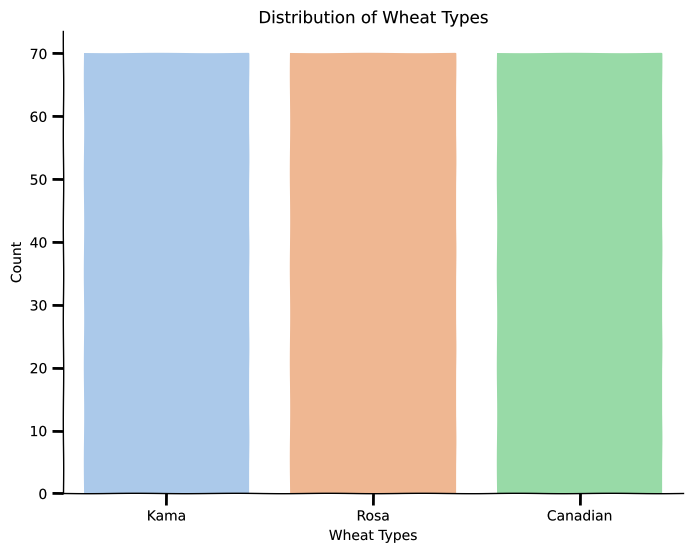

In [53]:
plt.figure(figsize=(8, 6))
sns.countplot(x='type', data=data, palette='pastel', hue='type')
sns.despine()
plt.title('Distribution of Wheat Types')
plt.xlabel('Wheat Types')
plt.ylabel('Count')
plt.show()

### Histogram

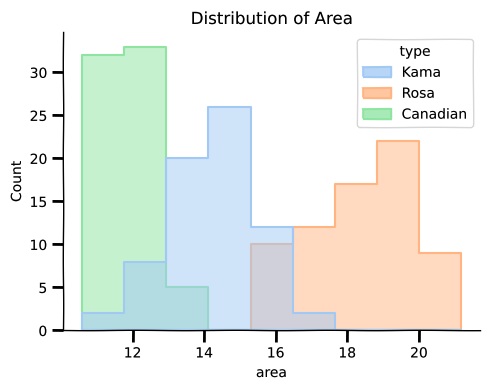

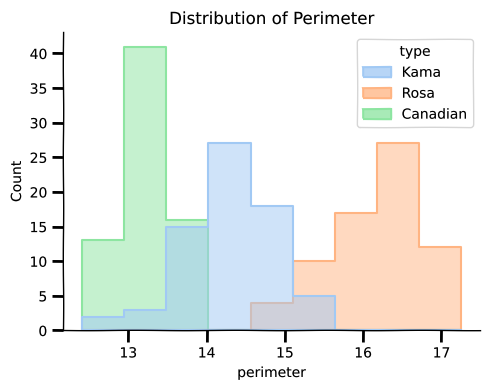

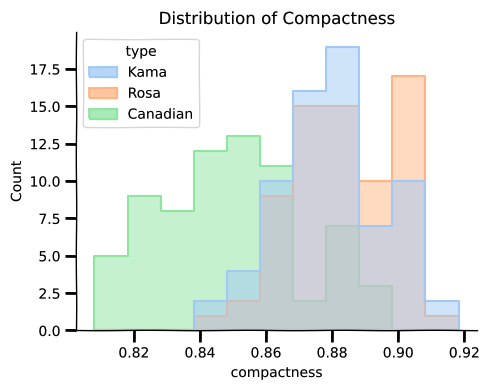

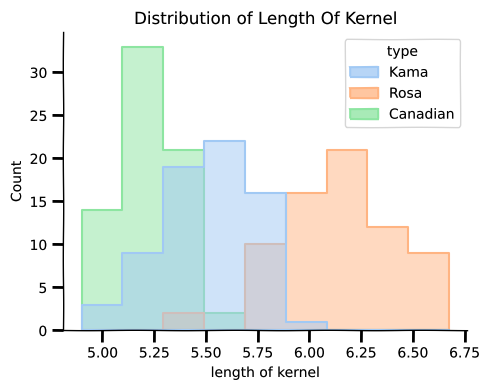

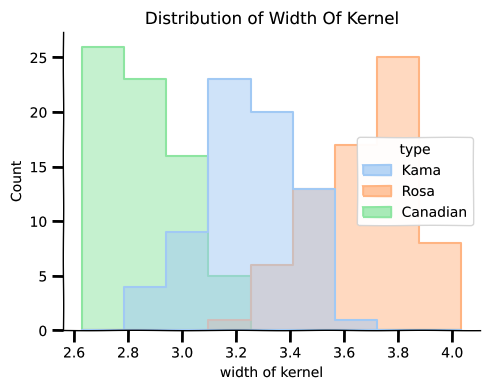

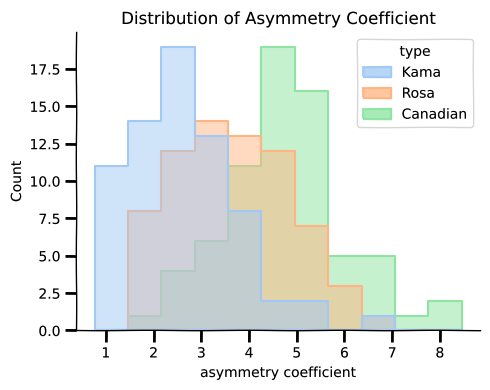

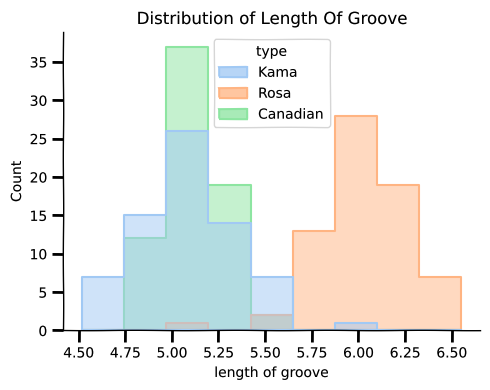

In [54]:
for feature in data.columns[:-1]:
    plt.figure(figsize=(5, 4))
    sns.histplot(
        data=data,
        x=feature,
        hue="type",
        # fill=True,
        alpha=0.5,
        element="step",
        linewidth=1.5,
        common_norm=False,
        palette="pastel",
        legend=True,
        # kde=True,
        # hue_order=[1, 2, 3],
    )
    sns.despine()
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(f"Distribution of {feature.title()}")
    plt.tight_layout()
    plt.show()

### BoxPlot


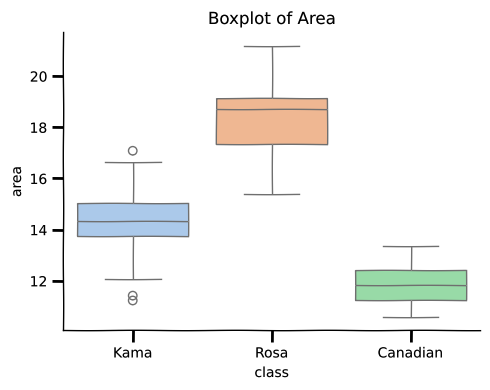

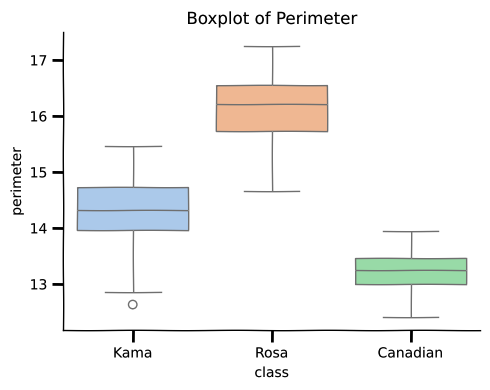

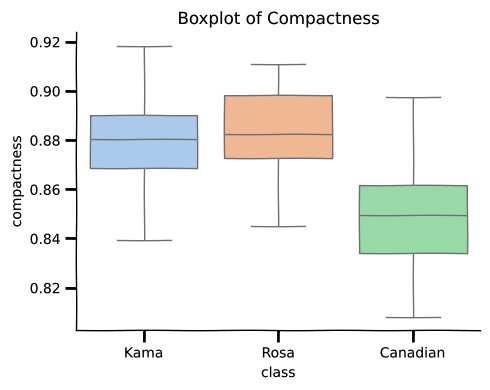

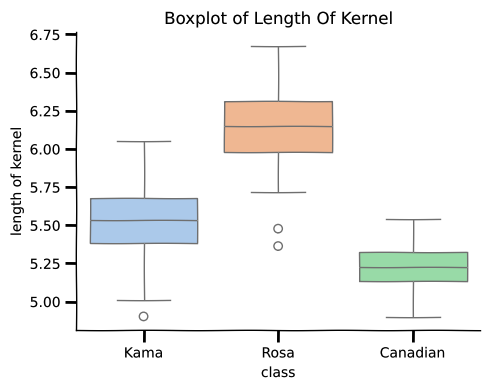

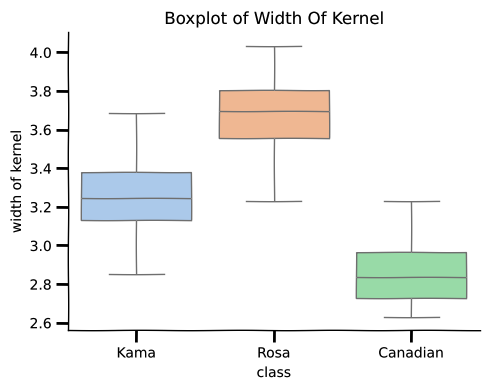

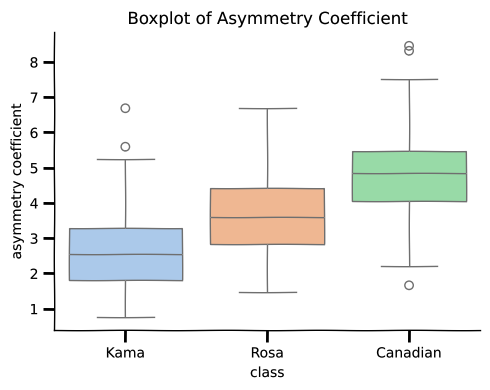

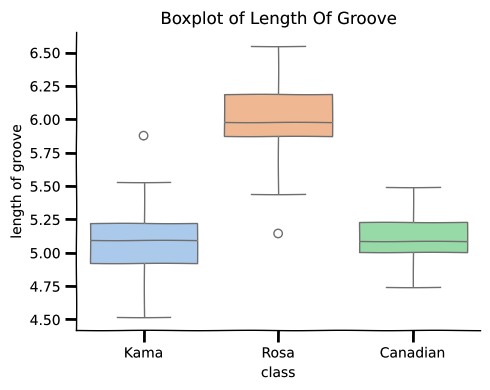

In [55]:
for feature in data.columns[:-1]:
    plt.figure(figsize=(5, 4))
    sns.boxplot(
        data=data,
        x="type",
        y=feature,
        palette="pastel",
        hue="type",
        # legend=True
    )
    sns.despine()
    plt.xlabel("class")
    plt.ylabel(feature)
    plt.title(f"Boxplot of {feature.title()}")
    plt.tight_layout()
    plt.show()

### Correlation Matrix


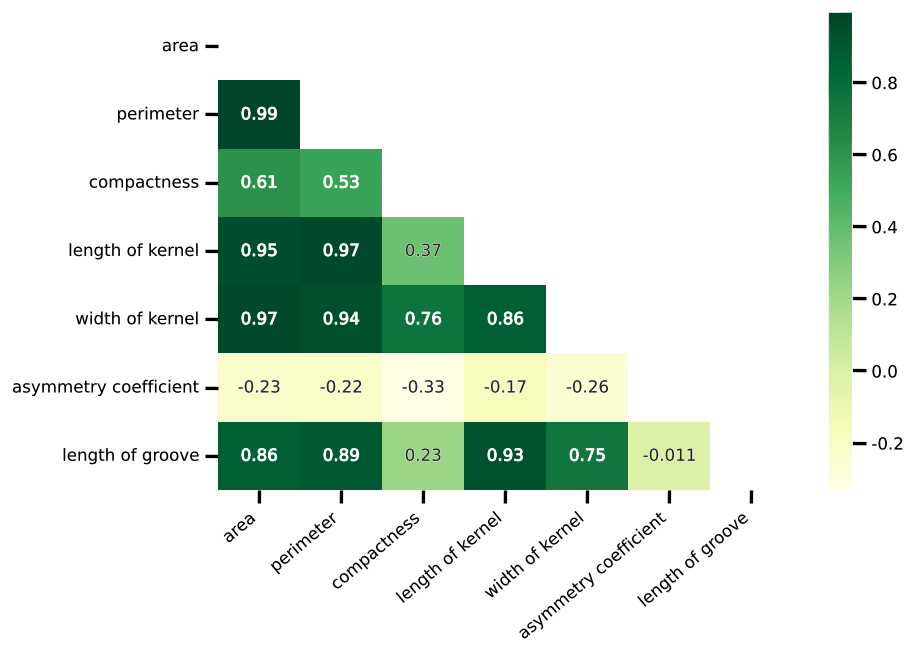

In [56]:
corr = data.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr))

plt.figure(figsize=(8, 6), dpi=120)
g = sns.heatmap(
    corr,
    annot=True,
    cmap="YlGn",
    mask=mask,
    # linewidth = 0.1
)

plt.tight_layout()
plt.grid(False)
plt.xticks(rotation=40, ha="right")
plt.yticks()

plt.show()

### Pairplot


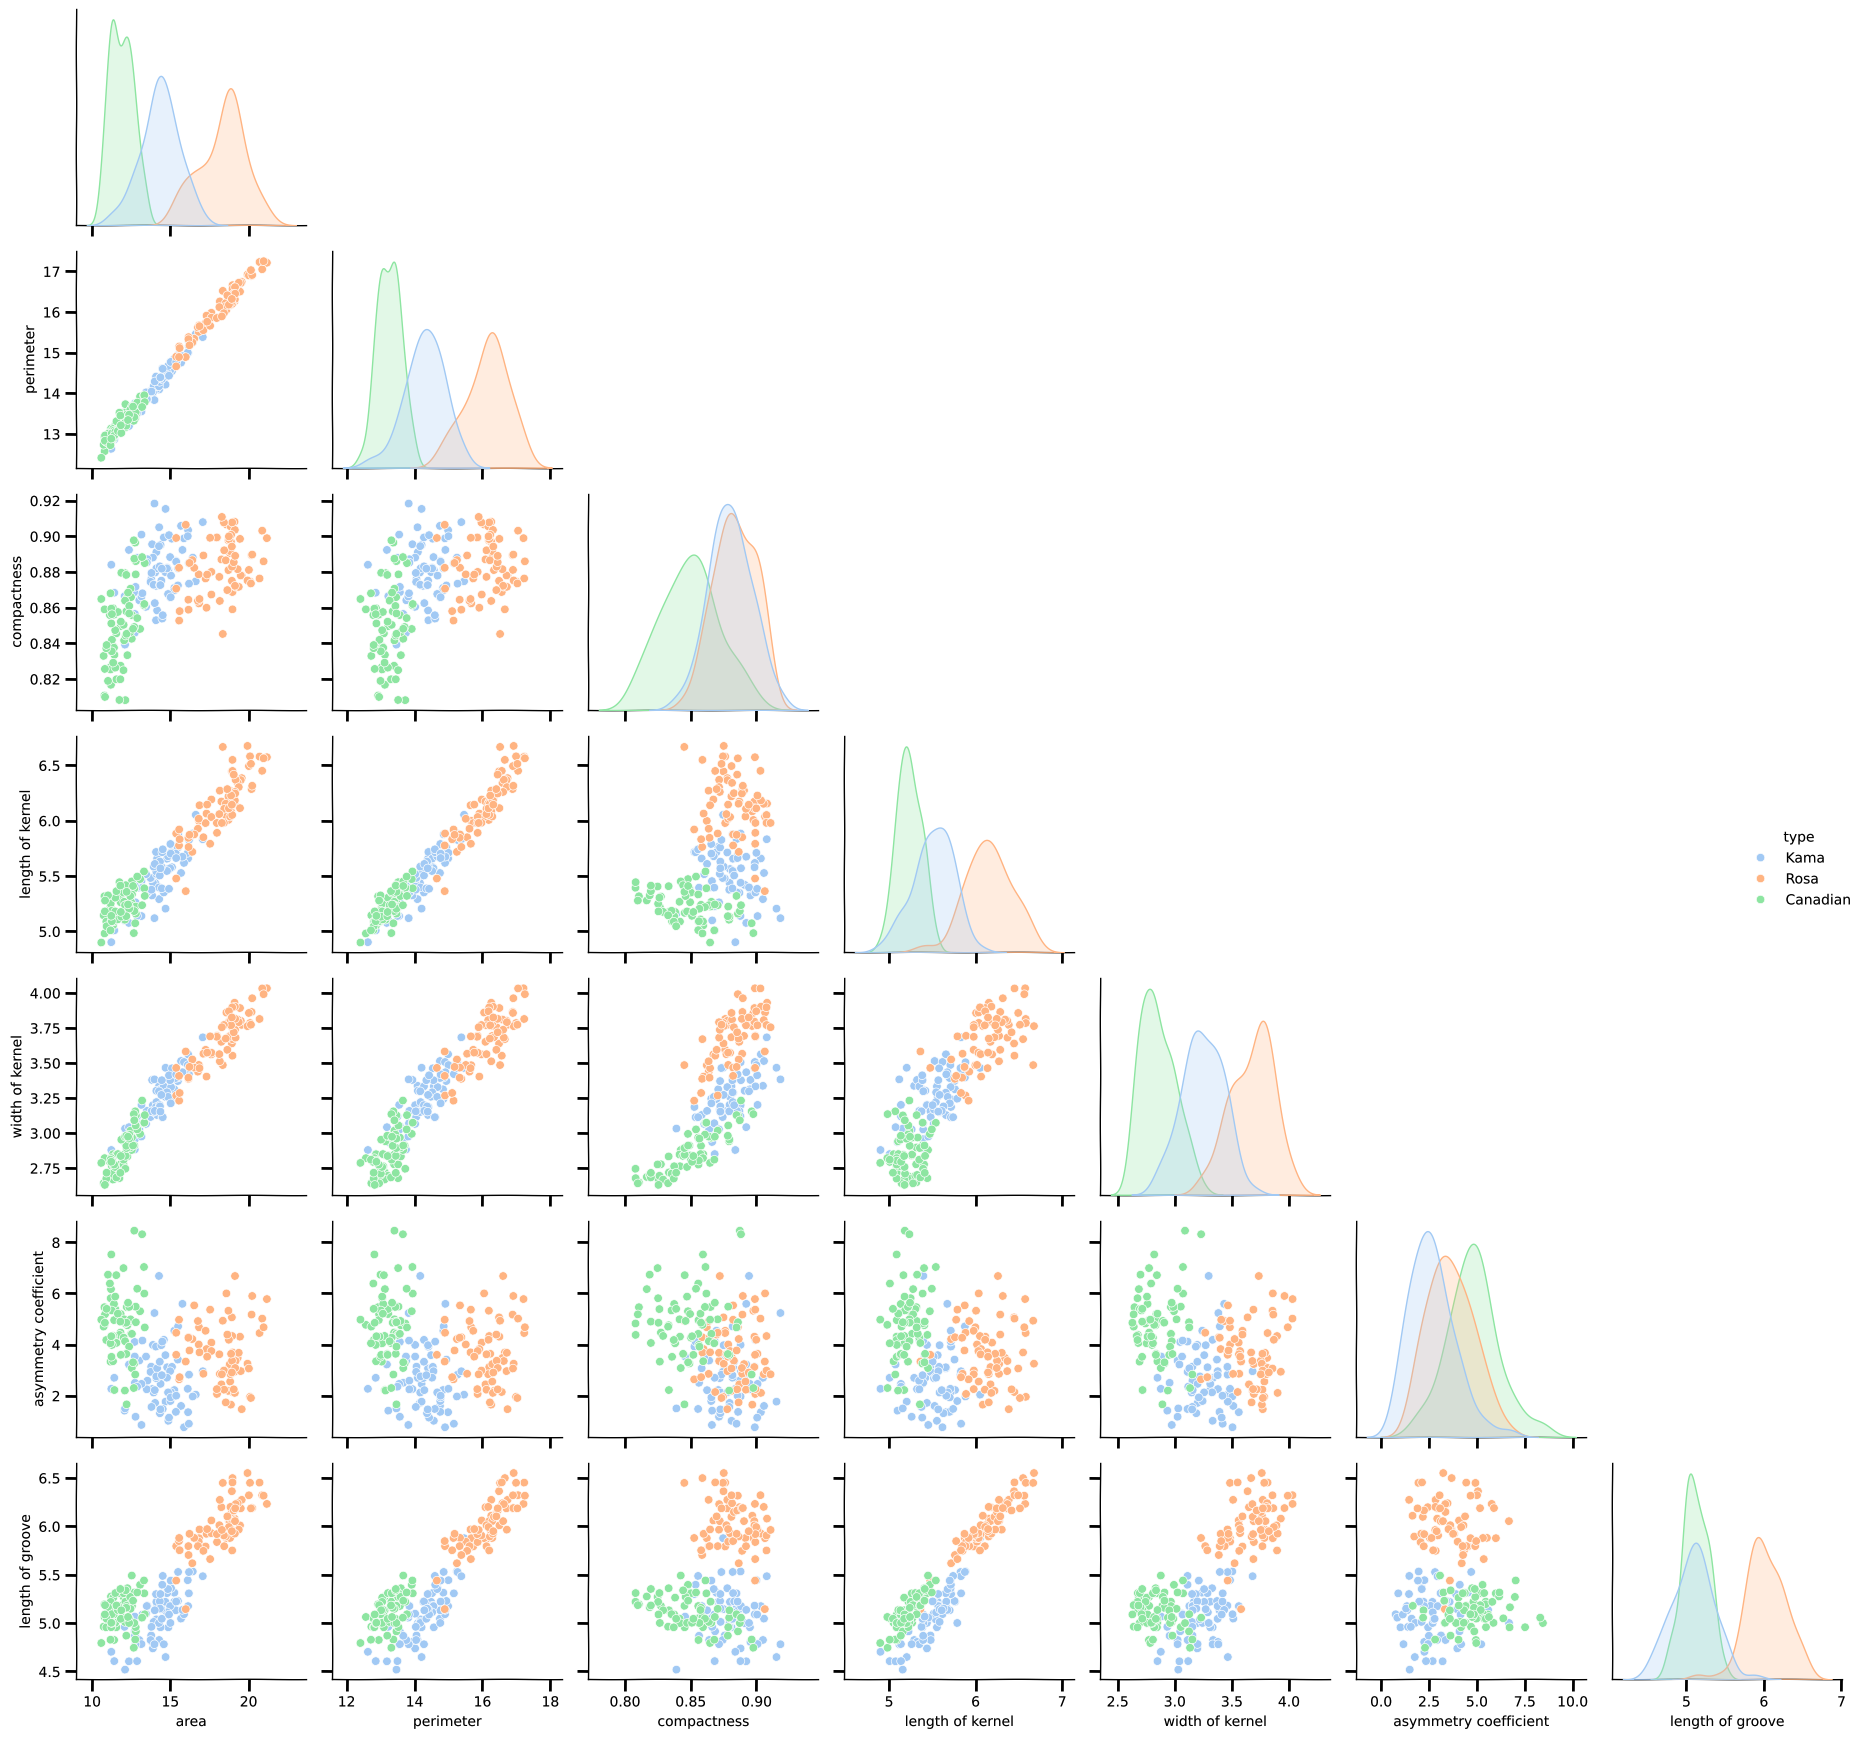

In [57]:
g = sns.pairplot(
    data,
    hue="type",
    palette="pastel",
    diag_kind="kde",
    # hue_order=hue_order,
    corner=True,
)
sns.despine()
plt.tight_layout()
plt.show()

## Prepare Data


In [58]:
RANDOM_STATE = 44
np.random.default_rng(RANDOM_STATE)

Generator(PCG64) at 0x163DA8E40

In [59]:
X = data.drop(columns=["type"])
y = data["type"]

In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

## KNN Classifier


In [62]:
error_rate = []

ks = 25
mean_acc = np.zeros(ks - 1)
std_acc = np.zeros(ks - 1)

k_range = range(1, ks)

for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))
    mean_acc[i - 1] = accuracy_score(y_test, pred_i)
    std_acc[i - 1] = np.std(pred_i == y_test) / np.sqrt(pred_i.shape[0])

optimal_k = k_range[np.argmin(error_rate)]

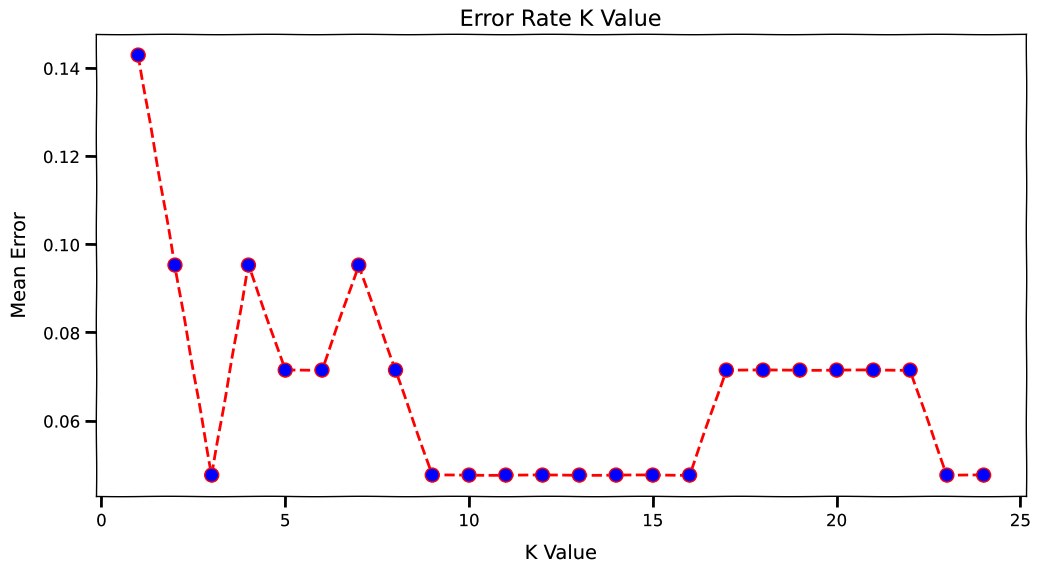

In [63]:
max_show = ks
plt.figure(figsize=(12, 6))
plt.plot(
    range(1, max_show),
    error_rate[: max_show - 1],
    color="red",
    linestyle="dashed",
    marker="o",
    markerfacecolor="blue",
    markersize=10,
)
plt.title("Error Rate K Value", fontdict={"fontsize": 16})
plt.xlabel("K Value", fontdict={"fontsize": 14}, labelpad=10)
plt.ylabel("Mean Error", fontdict={"fontsize": 14}, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

### Best K Value Model

In [64]:
optimal_k = k_range[np.argmin(error_rate)]

final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train, y_train)
y_pred = final_knn.predict(X_test)

In [65]:
print(f"model (K={optimal_k})")
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
precision = precision_score(y_test, y_pred, average="weighted")
print(f"Precision: {precision * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

model (K=3)
Accuracy: 95.24%
Precision: 95.62%

Classification Report:
              precision    recall  f1-score   support

    Canadian       0.93      1.00      0.96        13
        Kama       1.00      0.89      0.94        19
        Rosa       0.91      1.00      0.95        10

    accuracy                           0.95        42
   macro avg       0.95      0.96      0.95        42
weighted avg       0.96      0.95      0.95        42



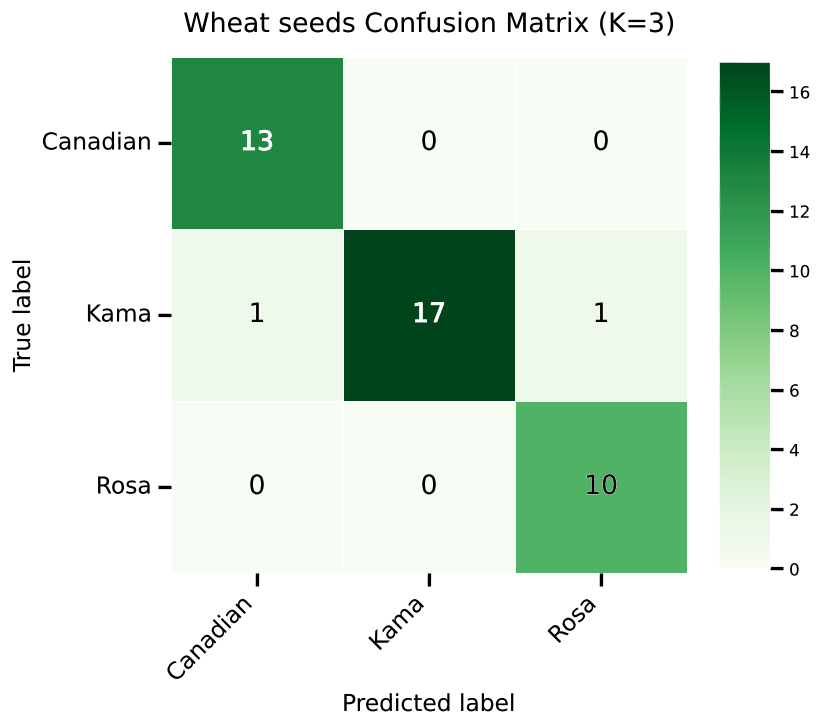

In [66]:
cm = confusion_matrix(y_test, y_pred)
cm_classes = np.unique(np.r_[y_test, y_pred])
plot_confusion_matrix(
    cm,
    cm_classes,
    title=f"Wheat seeds Confusion Matrix (K={optimal_k})",
)